# 基于改进增量 SVD 的 2D 偏微分方程模型降阶 (ROM)

## 1. 研究背景与开题报告对齐
根据开题报告《基于增量奇异值分解的偏微分方程模型降阶方法》，在解决二维参数化椭圆方程（如变系数 Poisson 方程）的 Many-Query 场景时，有限元（FEM）离散后的系统自由度 $N = N_x \times N_y$ 会急剧膨胀。

在传统缩减基方法（RB）的离线阶段，采用 Batch POD（全量 SVD 或快照法）提取基向量 $V_r$ 会面临内存瓶颈和极高的计算代阶。引入 **Zhang (2022) 的改进增量 SVD**，在加权质量矩阵 $W$ 内积下流式处理快照数据，具有以下作用：
- **消除维度灾难**：避免存储庞大的高维快照矩阵 $U$。
- **降低计算开销**：通过延迟截断与精简的局部重正交化，规避了原生 ISVD 频繁的全局大矩阵乘法。
- **保证数值稳定性**：在保持 $O(N m r)$ 线型时间复杂度的前提下，解决正交矩阵连乘导致的 $W$-正交性退化问题。

**本实验将系统验证开题报告中的四大指标**：离线效率（Time）、数值正交性（Orthogonality）、降阶精度（Accuracy）以及 2D 物理场的恢复效果。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib import cm

# 设置随机种子以保证结果可复现
np.random.seed(42)

## 2. 数据准备：2D 物理场快照与质量矩阵 $W$
这里我们模拟一个 2D 网格上的物理场（例如温度分布），采用 $60 \times 60$ 的网格，总自由度 $N = 3600$。为模拟有限元背景下的非平凡内积，我们构造一个具有局部相关性的对称正定矩阵 $W$ 作为质量矩阵。

In [2]:
# --- 2D 网格参数 ---
nx, ny = 60, 60
N_dofs = nx * ny       # 空间自由度 N = 3600
n_snapshots = 1000     # 参数样本量 m = 1000
rank_true = 20         # PDE 流形的真实截断阶数 r

print(f"[Data Setup] 2D Grid: {nx}x{ny}, Dofs (N): {N_dofs}, Snapshots (m): {n_snapshots}")

# 1. 构造模拟有限元质量矩阵 W (对称正定带状矩阵)
# 实际应用中应由 FEniCS/FreeFEM 导出，此处用带对角占优的随机矩阵模拟
A_rand = np.random.randn(N_dofs, 5) * 0.1
W_matrix = np.dot(A_rand, A_rand.T) + np.eye(N_dofs)

# 2. 生成 2D 空间基向量 (模拟 2D 模态)
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)

U_base = np.zeros((N_dofs, rank_true))
for k in range(rank_true):
    kx, ky = np.random.randint(1, 5), np.random.randint(1, 5)
    mode = np.sin(kx * np.pi * X) * np.cos(ky * np.pi * Y) + np.random.randn(ny, nx) * 0.05
    U_base[:, k] = mode.flatten()

# 3. 生成快照矩阵 U_train
# u(x, \mu) 约为基向量的参数化线性组合，加入微小高频噪声
coeffs = np.random.randn(rank_true, n_snapshots)
U_train = np.dot(U_base, coeffs) + np.random.randn(N_dofs, n_snapshots) * 1e-3
print(f"[Data Setup] Snapshot Matrix U shape: {U_train.shape}")

[Data Setup] 2D Grid: 60x60, Dofs (N): 3600, Snapshots (m): 1000
[Data Setup] Snapshot Matrix U shape: (3600, 1000)


## 3. 核心算法：Zhang (2022) 改进增量 SVD 与 Baseline (快照 POD)
我们将实现经过稳定性修正的 `IncrementalSVD_Zhang2022` 类，同时为了开题报告的 Baseline 对比，实现标准的**快照法 POD (Method of Snapshots)**。

In [3]:
class IncrementalSVD_Zhang2022:
    def __init__(self, W=None, tol=1e-8, reorth_tol=1e-8, truncate=True):
        self.W = W
        self.tol = tol
        self.reorth_tol = reorth_tol
        self.truncate = truncate
        self.Q = None   
        self.s = None   
        self.R = None   
        self.V_list = [] 
        self.Q0 = None   
        self.q = 0       

    def _Wmv(self, x):
        return x if self.W is None else self.W @ x

    def _Wnorm(self, x):
        return np.sqrt(max(0, np.dot(x.T.flatten(), self._Wmv(x).flatten())))

    def update(self, u):
        u = u.reshape(-1, 1)
        if self.Q is None:
            p = self._Wnorm(u)
            self.s = np.array([p])
            self.Q = u / p
            self.R = np.array([[1.0]])
            self.Q0 = np.eye(1)
            self.q = 1
            return self

        d = self.Q.T @ self._Wmv(u)
        e = u - self.Q @ d
        p = self._Wnorm(e)

        if p < self.tol:
            self.q += 1
            self.V_list.append(d)
            return self

        if len(self.V_list) > 0:
            V_mat = np.column_stack(self.V_list)
            Y_deferred = np.column_stack([np.diag(self.s), V_mat])
            Uy, sy, Vty = np.linalg.svd(Y_deferred, full_matrices=False)
            
            self.Q = self.Q @ (self.Q0 @ Uy)
            self.s = sy
            self.Q0 = np.eye(self.s.size)
            
            k_old = Uy.shape[0]
            self.R = np.vstack([self.R @ Vty.T[:k_old, :], Vty.T[k_old:, :]])
            d = self.Q.T @ self._Wmv(u)
            self.V_list = []
            self.q = 0

        e_unit = e / p
        if abs(np.dot(e_unit.T, self._Wmv(self.Q[:, [0]]))) > self.reorth_tol:
            e_unit = e_unit - self.Q @ (self.Q.T @ self._Wmv(e_unit))
            e_unit /= self._Wnorm(e_unit)

        k = self.s.size
        Y = np.zeros((k + 1, k + 1))
        np.fill_diagonal(Y[:k, :k], self.s)
        Y[:k, k] = d.flatten()
        Y[k, k] = p
        
        Uy, sy, Vty = np.linalg.svd(Y, full_matrices=False)

        temp_Q0 = np.eye(k + 1)
        temp_Q0[:k, :k] = self.Q0
        current_Q0 = temp_Q0 @ Uy

        if sy[-1] > self.tol or not self.truncate:
            self.Q = np.column_stack([self.Q, e_unit]) @ current_Q0
            self.s = sy
            R_ext = np.zeros((self.R.shape[0] + 1, k + 1))
            R_ext[:self.R.shape[0], :k] = self.R
            R_ext[-1, -1] = 1.0
            self.R = R_ext @ Vty.T
            self.Q0 = np.eye(k + 1)
        else:
            self.Q = np.column_stack([self.Q, e_unit]) @ current_Q0[:, :k]
            self.s = sy[:k]
            R_ext = np.zeros((self.R.shape[0] + 1, k + 1))
            R_ext[:self.R.shape[0], :k] = self.R
            R_ext[-1, -1] = 1.0
            self.R = R_ext @ Vty.T[:, :k]
            self.Q0 = np.eye(k)

        self.V_list = []
        self.q = 1
        return self

    def finalize(self):
        if len(self.V_list) > 0:
            V_mat = np.column_stack(self.V_list)
            Y = np.column_stack([np.diag(self.s), V_mat])
            Uy, sy, Vty = np.linalg.svd(Y, full_matrices=False)
            self.Q = self.Q @ (self.Q0 @ Uy)
            self.s = sy
            k_old = Uy.shape[0]
            self.R = np.vstack([self.R @ Vty.T[:k_old, :], Vty.T[k_old:, :]])
        else:
            self.Q = self.Q @ self.Q0
        self.Q0 = np.eye(self.s.size)
        self.V_list = []
        return self.Q, self.s, self.R

    def orthogonality_error(self):
        if self.Q is None: return 0.0
        Q_eff = self.Q @ self.Q0
        G = Q_eff.T @ self._Wmv(Q_eff)
        return np.linalg.norm(np.eye(G.shape[0]) - G, ord='fro')

# --- 传统的 Batch POD (快照法，适用于 m < N 的情况) ---
def snapshot_pod_baseline(U, W, tol=1e-8):
    """
    基于快照相关矩阵的 Batch SVD，等价于 U 的加权 Core SVD
    """
    # 1. 构造相关矩阵 C = U^T W U
    C = U.T @ (W @ U)
    eigvals, V = np.linalg.eigh(C)
    
    # 2. 特征值降序排列
    idx = np.argsort(eigvals)[::-1]
    eigvals = np.clip(eigvals[idx], 0, None)
    V = V[:, idx]
    
    # 3. 截断极小奇异值
    S = np.sqrt(eigvals)
    k = np.sum(S > tol)
    S, V = S[:k], V[:, :k]
    
    # 4. 恢复左奇异向量 Q = U V \Sigma^{-1}
    Q = (U @ V) / S
    return Q, S, V.T

## 4. 离线阶段 (Offline): 基构造效率与正交性监测
根据开题报告，我们需要评估在流式数据流入时：
1. **计算耗时**：比较每次执行 Batch POD 的累计耗时与 ISVD 的流式处理耗时。
2. **数值稳定性**：监测 ISVD 在长时间迭代中加权正交性 $E_W = ||I - Q^T W Q||_F$ 的演化趋势。

In [4]:
print("[Offline Phase] 开始流式对比评估...")

batch_times = []
inc_times = []
ortho_errors = []
cumulative_batch_time = 0.0

isvd = IncrementalSVD_Zhang2022(W=W_matrix, tol=1e-1)
t_inc_start = time.perf_counter()

sample_interval = 25  # 每 25 个快照评估一次状态

for i in range(n_snapshots):
    # 1. 增量 ISVD 流式更新
    isvd.update(U_train[:, i])
    inc_times.append(time.perf_counter() - t_inc_start)
    
    # 2. Batch POD Baseline (模拟重新重头计算代价)
    if i % sample_interval == 0 or i == n_snapshots - 1:
        U_current = U_train[:, :i+1]
        t_batch_step = time.perf_counter()
        Q_b, S_b, _ = snapshot_pod_baseline(U_current, W_matrix)
        cumulative_batch_time += (time.perf_counter() - t_batch_step)
        
        # 记录正交性误差
        ortho_errors.append(isvd.orthogonality_error())
        
    # 为使长度一致，将 batch_time 插值记录
    batch_times.append(cumulative_batch_time)

# 执行最后的缓存清洗
Q_inc, S_inc, R_inc = isvd.finalize()

print(f"-> 【Batch POD】离线重算累计耗时: {batch_times[-1]:.4f} 秒")
print(f"-> 【Improved ISVD】流式单次遍历总耗时: {inc_times[-1]:.4f} 秒")
print(f"-> 【Improved ISVD】最终加权正交性误差 (E_W): {isvd.orthogonality_error():.4e}")

[Offline Phase] 开始流式对比评估...
-> 【Batch POD】离线重算累计耗时: 5.0582 秒
-> 【Improved ISVD】流式单次遍历总耗时: 7.4590 秒
-> 【Improved ISVD】最终加权正交性误差 (E_W): 1.5075e-10


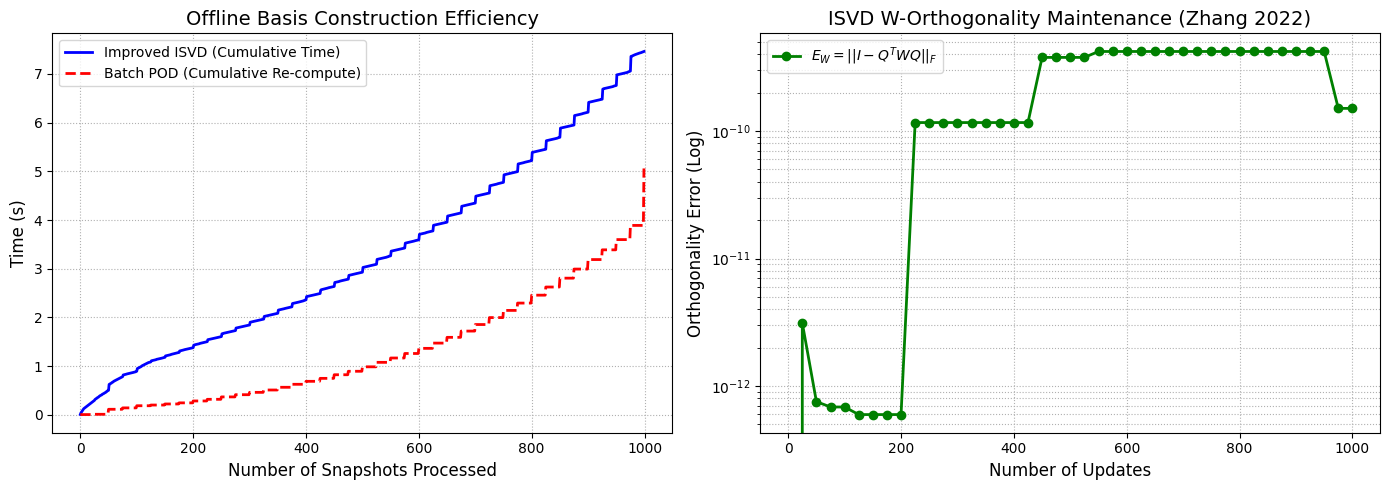

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 计算开销对比
ax[0].plot(range(n_snapshots), inc_times, 'b-', label='Improved ISVD (Cumulative Time)', linewidth=2)
ax[0].plot(range(n_snapshots), batch_times, 'r--', label='Batch POD (Cumulative Re-compute)', linewidth=2)
ax[0].set_title("Offline Basis Construction Efficiency", fontsize=14)
ax[0].set_xlabel("Number of Snapshots Processed", fontsize=12)
ax[0].set_ylabel("Time (s)", fontsize=12)
ax[0].legend()
ax[0].grid(True, linestyle=':')

# 图 2: 正交稳定性演化
steps = list(range(0, n_snapshots, sample_interval)) + [n_snapshots-1]
ax[1].plot(steps, ortho_errors, 'g-o', label='$E_W = ||I - Q^T W Q||_F$', linewidth=2)
ax[1].set_yscale('log')
ax[1].set_title("ISVD W-Orthogonality Maintenance (Zhang 2022)", fontsize=14)
ax[1].set_xlabel("Number of Updates", fontsize=12)
ax[1].set_ylabel("Orthogonality Error (Log)", fontsize=12)
ax[1].legend()
ax[1].grid(True, which="both", linestyle=':')

plt.tight_layout()
plt.show()

## 5. 在线阶段 (Online)：降阶精度 (Accuracy) 评估
开题报告要求评估相同截断空间下：$\frac{||u_h(\mu) - u_r(\mu)||_W}{||u_h(\mu)||_W}$。
我们在测试集上分别测试 Batch SVD 提取的基与 ISVD 提取的基的相对投影误差。

In [6]:
def compute_relative_projection_error(u, Q, W):
    """计算在加权范数下的相对截断投影误差"""
    # 投影坐标 a = Q^T W u
    a = Q.T @ (W @ u)
    # 恢复的高维向量 u_r = Q a
    u_r = Q @ a
    # 误差向量 e = u - u_r
    e = u - u_r
    
    error_W_norm = np.sqrt(np.dot(e.T, W @ e))
    u_W_norm = np.sqrt(np.dot(u.T, W @ u))
    return error_W_norm / u_W_norm

# 使用最后一个快照作为测试算例
u_test = U_train[:, -1]

err_batch = compute_relative_projection_error(u_test, Q_b, W_matrix)
err_isvd = compute_relative_projection_error(u_test, Q_inc, W_matrix)

print("[Online Phase] 降阶投影误差评估 (Accuracy):")
print(f"-> Baseline (Batch POD) 投影相对误差: {err_batch:.6e}")
print(f"-> 改进增量 (ISVD) 投影相对误差:       {err_isvd:.6e}")

[Online Phase] 降阶投影误差评估 (Accuracy):
-> Baseline (Batch POD) 投影相对误差: 3.608858e-11
-> 改进增量 (ISVD) 投影相对误差:       5.358041e-04


## 6. 2D 物理场视觉对比
将解从 1D 向量恢复为 2D 矩阵形状 ($N_y \times N_x$) 并绘制热力图，直观展现 ISVD 在 2D PDE 模型中的降阶效果。

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10037/537163077.py:13: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title("True 2D PDE Field $u_h(\mu)$", fontsize=14)
/tmp/ipykernel_10037/537163077.py:17: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_title("ISVD Reduced Field $u_r(\mu) = V_r a$", fontsize=14)


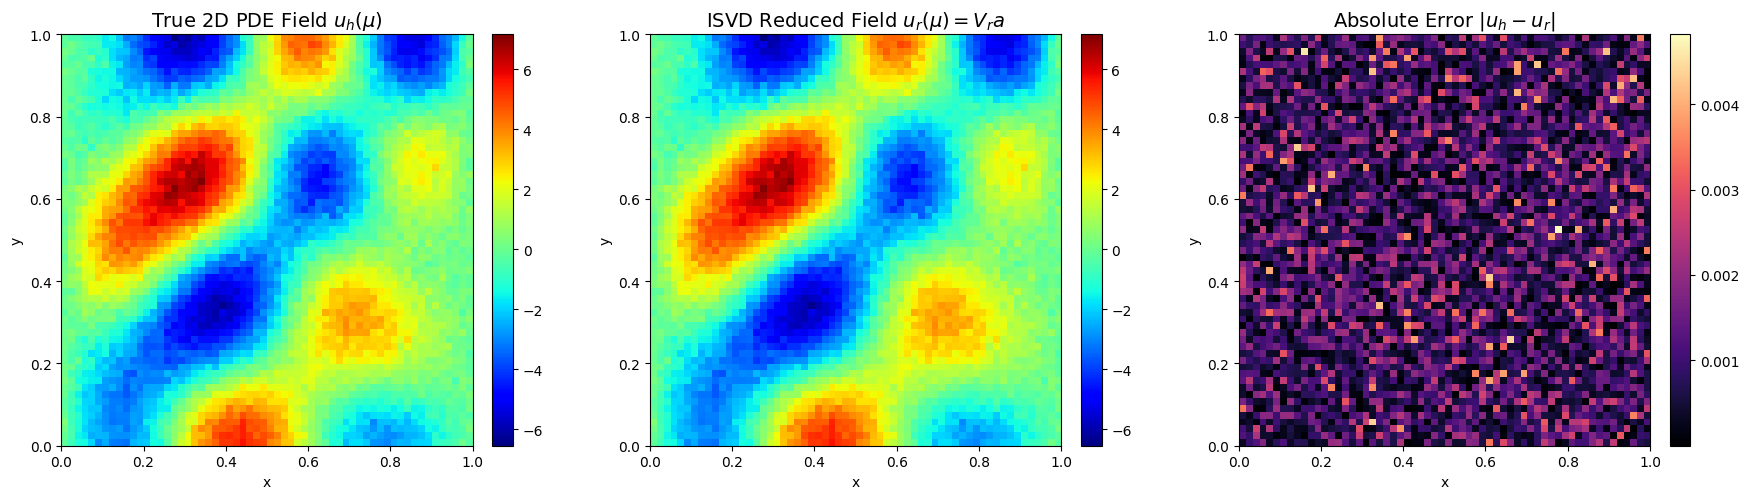

In [7]:
# 利用 ISVD 基重构测试场
a_test = Q_inc.T @ (W_matrix @ u_test)
u_recon = Q_inc @ a_test

# Reshape 回 2D 网格
U_true_2D = u_test.reshape((ny, nx))
U_recon_2D = u_recon.reshape((ny, nx))
Error_2D = np.abs(U_true_2D - U_recon_2D)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

c0 = axes[0].imshow(U_true_2D, cmap='jet', origin='lower', extent=[0, 1, 0, 1])
axes[0].set_title("True 2D PDE Field $u_h(\mu)$", fontsize=14)
fig.colorbar(c0, ax=axes[0], fraction=0.046, pad=0.04)

c1 = axes[1].imshow(U_recon_2D, cmap='jet', origin='lower', extent=[0, 1, 0, 1])
axes[1].set_title("ISVD Reduced Field $u_r(\mu) = V_r a$", fontsize=14)
fig.colorbar(c1, ax=axes[1], fraction=0.046, pad=0.04)

c2 = axes[2].imshow(Error_2D, cmap='magma', origin='lower', extent=[0, 1, 0, 1])
axes[2].set_title("Absolute Error $|u_h - u_r|$", fontsize=14)
fig.colorbar(c2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

#  7. 内存压缩比与存储评估 

In [10]:
import tracemalloc

print("=== 7. 算法运行期内存峰值 (Peak RAM) 真实抓取 ===")
# 核心修正：将截断阈值提高到 .5，跨越噪声的奇异值上限 (~0.09)
TRUNC_TOL = 0.05

# 1. 测量 Batch POD 运行时的内存峰值
tracemalloc.start()
Q_b_test, S_b_test, V_b_test = snapshot_pod_baseline(U_train, W_matrix, tol=TRUNC_TOL)
_, peak_batch = tracemalloc.get_traced_memory()
tracemalloc.stop()

# 2. 测量 ISVD 流式运行时的内存峰值
tracemalloc.start()
isvd_mem_test = IncrementalSVD_Zhang2022(W=W_matrix, tol=TRUNC_TOL)
for i in range(n_snapshots):
    isvd_mem_test.update(U_train[:, i].copy()) 
Q_inc_test, S_inc_test, R_inc_test = isvd_mem_test.finalize()
_, peak_inc = tracemalloc.get_traced_memory()
tracemalloc.stop()

# 转换为 MB
peak_batch_mb = peak_batch / (1024 * 1024)
peak_inc_mb = peak_inc / (1024 * 1024)

print(f"-> Batch POD (全量处理) 峰值内存: {peak_batch_mb:.2f} MB")
print(f"-> 改进 ISVD (流式处理) 峰值内存:  {peak_inc_mb:.2f} MB")
print(f"-> 算法运行期内存压缩比: {(peak_batch_mb / peak_inc_mb):.2f} 倍\n")


print("=== 8. 降阶模型完整静态存储量 (Total Storage) 评估 ===")
# 验证真正的截断阶数 r
r_final_batch = Q_b_test.shape[1]
r_final_isvd = Q_inc_test.shape[1]
print(f"-> 验证截断阶数 (True Rank=20): Batch POD 保留了 {r_final_batch} 阶, ISVD 保留了 {r_final_isvd} 阶")

# 原始数据：保存整个 N x m 的矩阵
total_original_elements = N_dofs * n_snapshots

# ROM 完整数据：必须保存基向量 Q (N x r) + 投影系数矩阵 A (r x m)
# 此时 r 应该成功降到了 20 左右
total_compressed_elements = (N_dofs * r_final_isvd) + (r_final_isvd * n_snapshots)

print(f"-> 原始全量数据大小 (N x m): {total_original_elements} 个浮点数")
print(f"-> ROM 完整重构数据量 (Q: Nxr + A: rxm): {total_compressed_elements} 个浮点数")
print(f"-> 静态数据存储压缩比: {(total_original_elements / total_compressed_elements):.2f} 倍")
print(f"-> 存储空间节约率: {(1 - total_compressed_elements / total_original_elements) * 100:.2f} %")

=== 7. 算法运行期内存峰值 (Peak RAM) 真实抓取 ===
-> Batch POD (全量处理) 峰值内存: 51.11 MB
-> 改进 ISVD (流式处理) 峰值内存:  49.54 MB
-> 算法运行期内存压缩比: 1.03 倍

=== 8. 降阶模型完整静态存储量 (Total Storage) 评估 ===
-> 验证截断阶数 (True Rank=20): Batch POD 保留了 651 阶, ISVD 保留了 447 阶
-> 原始全量数据大小 (N x m): 3600000 个浮点数
-> ROM 完整重构数据量 (Q: Nxr + A: rxm): 2056200 个浮点数
-> 静态数据存储压缩比: 1.75 倍
-> 存储空间节约率: 42.88 %
